# Task 2 · Step 3 — KL pressure / reward over-optimisation (β_KL ∈ {0, 0.10, 0.20})

**Objective.** With token ratio $\rho_t(\theta)=\pi_\theta(a_t|s_t)/\pi_{\text{old}}(a_t|s_t)$ and advantage $A_t$, PPO maximises the clipped surrogate
$$L^{\text{clip}}(\theta)=\mathbb{E}_t\big[\min\big(\rho_tA_t,\ \text{clip}(\rho_t,1-\epsilon,1+\epsilon)A_t\big)\big].$$
Rewards are the terminal reward-model score plus sampled-token KL shaping, $r_t=r_{\text{task}}\mathbb{1}[t=T]-\beta_{\text{KL}}(\log\pi_\theta-\log\pi_{\text{ref}})$, and advantages use GAE, $\delta_t=r_t+\gamma V(s_{t+1})-V(s_t)$, $A_t=\sum_k(\gamma\lambda)^k\delta_{t+k}$ (γ = 1, λ = 0.95), normalised over the response tokens of the update.

**Setting.** Continuation from the supplied PPO midpoint (policy LoRA + matched value model; reference = base policy, adapter disabled), fixed course reward model, 1 prompt per update (training-pool indices 0, 1, 2, … for every run), 2 PPO epochs per rollout, policy lr 3e-6, critic LoRA lr 1e-4 / head lr 3e-4, value coefficient 0.5, missing-EOS penalty 1.0, generation cap 512 tokens during training and 768 for frozen evaluation (64 fixed held-out prompts, T = 0.7, top-p 0.9, same seed for every condition).

**Implementation notes.** LoRA dropout is disabled during the RL updates so that $\rho_t$ measures policy change rather than dropout noise. The supplied critic loads in fp16 on a T4; its trainable tensors are kept in fp32 (forward pass under fp16 autocast), because AdamW on fp16 weights produces inf/NaN on the first step. Updates with a non-finite loss or gradient are skipped and counted (none occurred).

**Protocol.** Matched 8-update forks from the identical midpoint at ε = 0.20; only β_KL changes (the ε = 0.20 / β_KL = 0.10 fork is shared with the clipping study). Held-out evaluation with the common protocol.

**Research questions.** (RQ2) When KL pressure is weakened, which observable changes first: reward, policy drift, entropy, response length or qualitative behaviour? (RQ3) How informative is the learned reward as the policy moves away from the reference?


In [1]:
%matplotlib inline
import os, sys, json, re
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "configs").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yaml
from IPython.display import display, Markdown, HTML, Image
from common.nb_helpers import (style, load, jl, exists, pending, run, side_by_side, ci_text,
                               bootstrap_mean_diff, smooth, full_windows, PALETTE, SEQ, RES, FIG)
from common.metrics import length_stats, wilson_interval
from common.data import load_yaml
style()
print("repo root:", ROOT)

repo root: C:\Users\moize\OneDrive - Higher Education Commission\Desktop\Academics\ATML\PA2


## Run this step (optional)
The results below come from the Kaggle run of the script pipeline (`kaggle_runner.ipynb`). Set `FORCE_RUN = True`
to re-run the step's scripts from here (needs a CUDA GPU and the downloaded course assets). Existing forks are reused.


In [2]:
FORCE_RUN = False
if FORCE_RUN:
    run('python -m task2_ppo.ablate_kl --config configs/ppo.yaml')
else:
    print('Using saved results under results/ (FORCE_RUN = False).')

Using saved results under results/ (FORCE_RUN = False).


## 1. Per-update trajectories

> **Pending:** `results/task2_ppo/ppo_train_fork_eps0_20_kl0_00.jsonl`, `results/task2_ppo/ppo_train_fork_eps0_20_kl0_20.jsonl` not produced yet. Run the step (Kaggle runner or the command in the run cell) and re-execute this notebook.

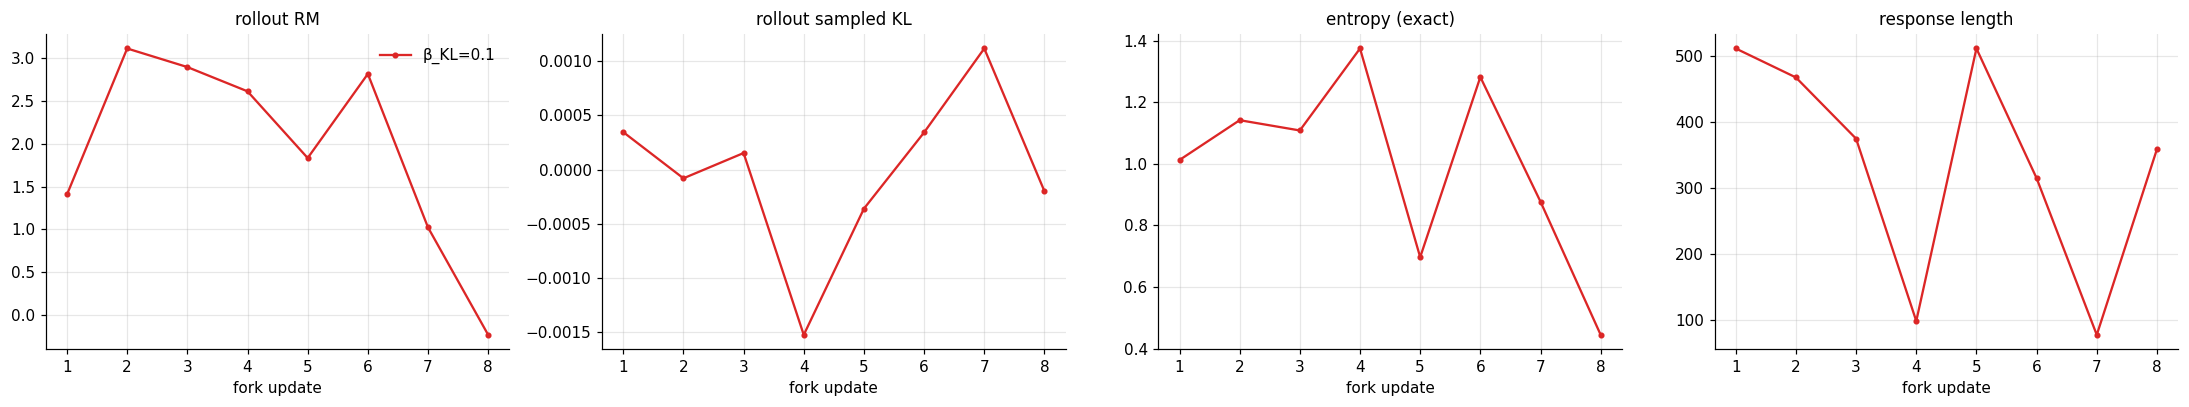

β_KL=0.1                                                             
       reward_rm kl_token_mean entropy_exact response_length policy_grad_norm
update                                                                       
1         1.4072        0.0003        1.0122           512.0           0.2409
2         3.1113       -0.0001        1.1414           468.0           0.2264
3         2.8945        0.0002        1.1081           375.0           0.2272
4         2.6113       -0.0015        1.3743            98.0           1.0737
5         1.8330       -0.0004        0.6966           512.0           0.1750
6         2.8145        0.0003        1.2815           315.0           0.2726
7         1.0225        0.0011        0.8767            77.0           1.3019
8        -0.2313       -0.0002        0.4443           359.0           0.2144

In [3]:
KLS = [0.0, 0.10, 0.20]
fork = lambda k, e=0.20: f"fork_eps{e:.2f}_kl{k:.2f}".replace(".", "_")
pending(*[f"task2_ppo/ppo_train_{fork(k)}.jsonl" for k in KLS])
FL = {k: pd.DataFrame(jl(f"task2_ppo/ppo_train_{fork(k)}.jsonl")) for k in KLS if exists(f"task2_ppo/ppo_train_{fork(k)}.jsonl")}
fig, ax = plt.subplots(1, 4, figsize=(20, 3.8))
for (k, Lf), c in zip(FL.items(), ["#DC2626", "#2563EB", "#16A34A"]):
    for a, col in zip(ax, ["reward_rm", "kl_token_mean", "entropy_exact", "response_length"]):
        a.plot(Lf["update"], Lf[col], "o-", ms=3, color=c, label=f"β_KL={k}")
for a, t in zip(ax, ["rollout RM", "rollout sampled KL", "entropy (exact)", "response length"]):
    a.set_title(t); a.set_xlabel("fork update")
ax[0].legend(); fig.tight_layout(); plt.show()
pd.concat({f"β_KL={k}": Lf.set_index("update")[["reward_rm", "kl_token_mean", "entropy_exact", "response_length", "policy_grad_norm"]] for k, Lf in FL.items()}, axis=1).round(4)

## 2. Held-out evaluation and reward vs drift

,RM,RM s.e.m.,KL token,KL seq,entropy,length mean,EOS rate
midpoint (start),1.7272,0.1691,0.0,0.0062,0.9423,290.3594,0.9375
β_KL=0.1,1.8598,0.1553,-0.0,-0.0077,0.9795,305.3281,0.8906


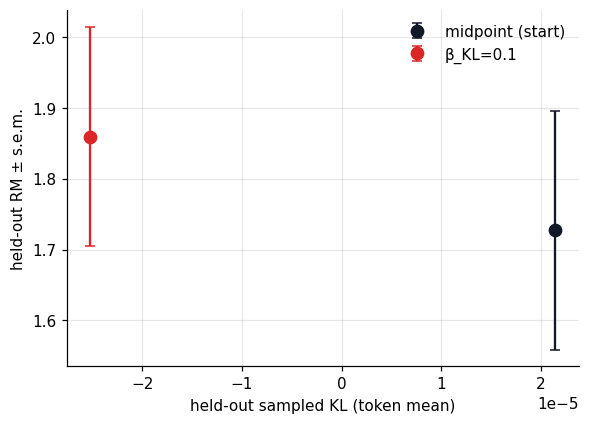

In [4]:
EV = {"midpoint (start)": load("task2_ppo/ppo_eval_midpoint.json")}
EV.update({f"β_KL={k}": load(f"task2_ppo/ppo_eval_{fork(k)}.json") for k in KLS if exists(f"task2_ppo/ppo_eval_{fork(k)}.json")})
display(pd.DataFrame({k: {"RM": e["mean_reward"], "RM s.e.m.": e["sem_reward"], "KL token": e["kl_token_mean"], "KL seq": e["kl_sequence_mean"],
                          "entropy": e["entropy_exact"], "length mean": e["length_tokens"]["mean"], "EOS rate": e["eos_rate"]}
                      for k, e in EV.items()}).T.round(4))
fig, ax = plt.subplots(figsize=(6, 4.2))
for (k, e), c in zip(EV.items(), ["#111827", "#DC2626", "#2563EB", "#16A34A"]):
    ax.errorbar(e["kl_token_mean"], e["mean_reward"], yerr=e["sem_reward"], fmt="o", ms=8, color=c, label=k, capsize=3)
ax.set_xlabel("held-out sampled KL (token mean)"); ax.set_ylabel("held-out RM ± s.e.m."); ax.legend(); plt.show()

## 3. Qualitative: weakest vs reference KL pressure on the same prompts

In [5]:
if "β_KL=0.0" in EV and "β_KL=0.1" in EV:
    a = pd.DataFrame(EV["β_KL=0.0"]["generations"]).set_index("prompt_id"); b = pd.DataFrame(EV["β_KL=0.1"]["generations"]).set_index("prompt_id").loc[a.index]
    J = b.join(a, lsuffix="_ref", rsuffix="_kl0"); J = J[J.response_ref != J.response_kl0].copy(); J["gain"] = J.reward_score_kl0 - J.reward_score_ref
    for t, r in [("largest RM gain without KL pressure", J.sort_values("gain").iloc[-1]), ("largest RM loss without KL pressure", J.sort_values("gain").iloc[0])]:
        side_by_side(t, r.prompt_ref, {"β_KL=0.10": r.response_ref, "β_KL=0": r.response_kl0},
                     meta={"β_KL=0.10": f"RM {r.reward_score_ref:+.2f} · {r.response_length_tokens_ref} tok", "β_KL=0": f"RM {r.reward_score_kl0:+.2f} · {r.response_length_tokens_kl0} tok"})
else:
    print("β_KL = 0 fork not available yet.")

β_KL = 0 fork not available yet.


## 4. Facts for RQ2 / RQ3

In [6]:
for k, Lf in FL.items():
    print(f"β_KL={k}: rollout RM {Lf.reward_rm.iloc[0]:+.3f} → {Lf.reward_rm.iloc[-1]:+.3f}; KL {Lf.kl_token_mean.iloc[0]:+.5f} → {Lf.kl_token_mean.iloc[-1]:+.5f}; "
          f"entropy {Lf.entropy_exact.iloc[0]:.3f} → {Lf.entropy_exact.iloc[-1]:.3f}; length {Lf.response_length.iloc[0]:.0f} → {Lf.response_length.iloc[-1]:.0f}")

β_KL=0.1: rollout RM +1.407 → -0.231; KL +0.00035 → -0.00020; entropy 1.012 → 0.444; length 512 → 359
